# 02 - exploratory data analysis

**purpose**: explore ravdess audio data - class distribution, durations, waveforms, mel spectrograms, speaker demographics.

**input**: `data/processed/split_labels.csv + wav files`

**output**: save visualizations and summary statistics here: `docs/02-results/`

In [1]:
import sys
sys.path.append('../../')

**import dependencies**. we load numpy for numerics, matplotlib for plotting, and the project settings and eda helper.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from src.config.config import settings
from src.utils.eda import load_labels

load data

In [3]:
df = load_labels()
df.head()

,filepath,split,channel,emotion_code,emotion,intensity,actor,gender,statement,repetition
0,E:\career\projects\lightweight-speech-emotion-...,train,speech,1,neutral,normal,1,male,1,1
1,E:\career\projects\lightweight-speech-emotion-...,train,speech,1,neutral,normal,1,male,1,2
2,E:\career\projects\lightweight-speech-emotion-...,train,speech,1,neutral,normal,1,male,2,1
3,E:\career\projects\lightweight-speech-emotion-...,train,speech,1,neutral,normal,1,male,2,2
4,E:\career\projects\lightweight-speech-emotion-...,train,speech,2,calm,normal,1,male,1,1


**check shape and split sizes**. we confirm the dataframe dimensions and the train/val/test counts match what we expect from the previous notebook.

In [4]:
print(f"shape: {df.shape}")
print(f"splits: {df['split'].value_counts().to_dict()}")

shape: (2452, 10)
splits: {'train': 1932, 'val': 312, 'test': 208}


Intensity Distribution

In [5]:
emotion_counts = df['emotion'].value_counts()
emotion_counts

emotion
unknown    384
calm       376
happy      376
sad        376
angry      376
fearful    376
neutral    188
Name: count, dtype: int64

**bar chart of emotion distribution**. we visualize the emotion counts to quickly see the imbalance. the plot is saved to `docs/02-results/figures/` for use in reports.

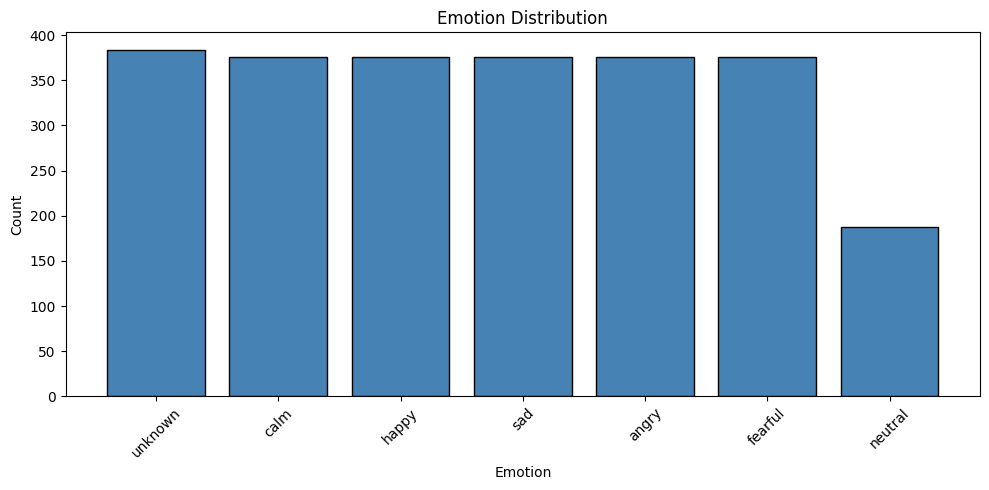

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(emotion_counts.index, emotion_counts.values, 
       color='steelblue', edgecolor='black')
ax.set_title('Emotion Distribution')
ax.set_xlabel('Emotion')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(str(settings.FIGURES_DIR / 'fig02-emotion-distribution.png'), dpi=120, bbox_inches='tight')
plt.show()

**count speech vs song**. we check how many samples come from each channel. this tells us the dataset composition.

In [7]:
channel_counts = df['channel'].value_counts()
channel_counts

channel
speech    1440
song      1012
Name: count, dtype: int64

**pie chart of speech vs song**. a visual breakdown showing that speech accounts for ~59% and song ~41% of the data.

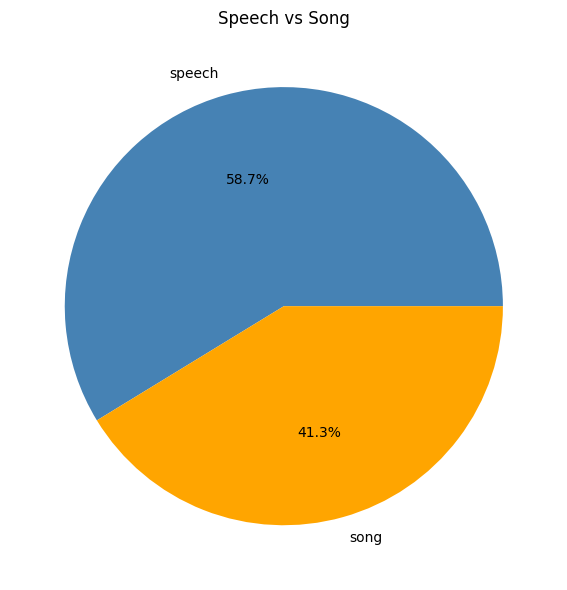

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(channel_counts.values, 
       labels=channel_counts.index,
       autopct='%1.1f%%',
       colors=['steelblue', 'orange'])
ax.set_title('Speech vs Song')
plt.tight_layout()
plt.savefig(str(settings.FIGURES_DIR / 'fig02-speech-vs-song.png'), dpi=120, bbox_inches='tight')
plt.show()

**count by gender**. we check how many samples come from male vs female actors at the sample level (not actor level).

In [9]:
gender_counts = df['gender'].value_counts()
gender_counts

gender
male      1248
female    1204
Name: count, dtype: int64

**bar chart of gender distribution**. a visual check of gender balance across the full dataset. male samples slightly outnumber female.

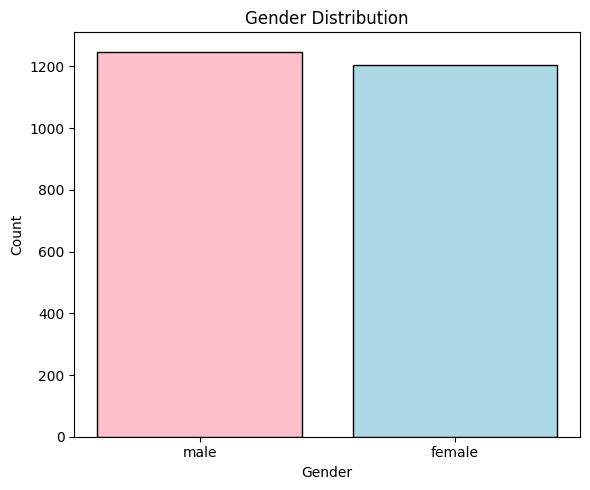

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(gender_counts.index, gender_counts.values,
       color=['pink', 'lightblue'], edgecolor='black')
ax.set_title('Gender Distribution')
ax.set_xlabel('Gender')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(str(settings.FIGURES_DIR / 'fig02-gender-distribution.png'), dpi=120, bbox_inches='tight')
plt.show()

**count by intensity**. ravdess labels each clip with 'normal' or 'strong' emotional intensity. we check how the intensity labels are distributed.

In [11]:
intensity_counts = df['intensity'].value_counts()
intensity_counts

intensity
normal    1320
strong    1132
Name: count, dtype: int64

**bar chart of intensity distribution**. a visual check showing normal and strong intensities are relatively balanced across the dataset.

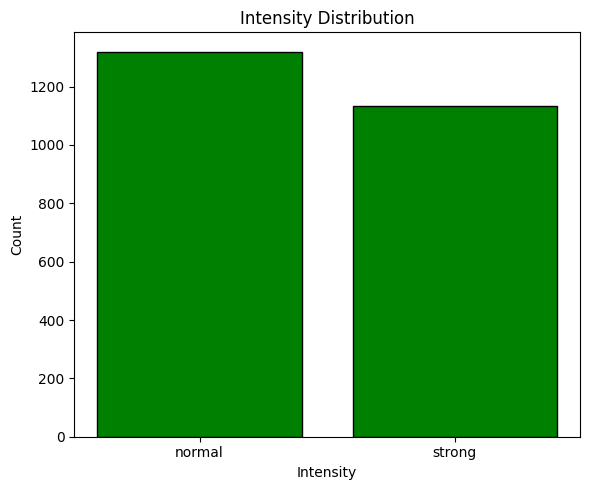

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(intensity_counts.index, intensity_counts.values,
       color='green', edgecolor='black')
ax.set_title('Intensity Distribution')
ax.set_xlabel('Intensity')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(str(settings.FIGURES_DIR / 'fig02-intensity-distribution.png'), dpi=120, bbox_inches='tight')
plt.show()